# Viterbi Physics Backbone


## Environment Setup

In [1]:
import os
import glob
import numpy as np
np.random.seed(12345)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))

pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Running on Local Environment
Data Directory: ../data
Extracted Well Names:
773 Well Names


## Pre Processing

In [3]:
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr

HW_LOW_PASS_CUTOFF = 0.009
HW_LOW_PASS_CUTOFF = 0.4
def remove_rotation_noise(gr_series, cutoff=HW_LOW_PASS_CUTOFF):
    """Low pass filter."""
    gr_filled = gr_series.interpolate(method='linear').bfill().ffill()
    nyquist = 0.5 
    normal_cutoff = cutoff / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, gr_filled)
    # return gr_filled.values

def pre_process(well):
    hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
    tw = pd.read_csv(train_data + f"/{well}__typewell.csv")

    mask = np.isnan(hw['TVT_input'].values)
    evalz = hw[mask]
    known = hw[~mask].copy().sort_values(by='TVT_input')
    tvt0 = hw[~mask]['TVT_input'].iloc[-1]

    # Z
    m_z, c_z = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
    z = (m_z * evalz['MD'].values + c_z) - evalz['Z'].values

    # Evalz - GR
    gr = remove_rotation_noise(evalz['GR']) 

    # TW
    tw_tvt = tw['TVT'].values
    tw_gr = tw['GR'].values
    
    
    return z, gr, tvt0, tw_gr, tw_tvt, 
    

In [4]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

In [5]:
PEAK_PROMINENCE = 5.0
PEAK_DISTANCE = 50
from scipy.signal import find_peaks
def find_midpoints(x_, y_, prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE):

    x = x_.copy().reset_index(drop=True)
    y = remove_rotation_noise(y_.copy().reset_index(drop=True))
    
    # The 'prominence' value requires tuning based on your specific data's scale.
    # 'distance' ensures you don't get two peaks right next to each other.
    peaks, properties = find_peaks(y, prominence=prominence, distance=distance)
    
    midpoints = (peaks[:-1] + peaks[1:]) // 2
    boundaries = [0] + midpoints.tolist() + [len(y)]

    # return peaks, properties, midpoints, boundaries
    return sorted(boundaries)

## Finding the correct trajectory

Process:
* Project all possible TVT+Z value anchors using `max_m_range`, with fixed `anchor_density` per TVT + Z.
* For every chunk, match all anchors (prev to next) except those with slope greater than `max_m`.
* Find join candidates, find losses joining them and add them to base loss of previous joins.
* For each of the next anchor, assign the prev anchor of least error.
* Then finally back track.

Extra bits of information not used:
* Matching Grs from GR vs Z, GR vs TVT.
* Faults, abruptly changing TVT.
* Signal Normalization, Rolling Correlation, etc.
* Signal matching form previously predicted chunks, known hw.
* Chunks division should have been made where correlation dies.
* hw of wells with the same type well can be used as type wells.
* Near by wells can be used as a type well as they have TVT vs GR

In [6]:
x_paths_to_show=5
min_separation_tvt=7.0
pool_size=1000
pool_size=float('inf')
c = 2.0 
def find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt):

    # Anchors for chunk = (Z+TVT)_0 + m * MD
    global anchors
    # Z + TVT, TVT_pred[0] is 0
    initial_anchor = -z[0]
    anchors = [np.array([initial_anchor])]

    # num_candidates is arbitrary
    # (num_chunks * num_candidates)
    for i in range(1, len(boundaries)):
        current_md_steps = boundaries[i]
        min_anchor = initial_anchor + (-max_m_range * current_md_steps)
        max_anchor = initial_anchor + (max_m_range * current_md_steps)
        
        num_candidates = (max_anchor - min_anchor) * anchor_density
        num_candidates = max(int(num_candidates), 1)
        
        anchors.append(np.linspace(min_anchor, max_anchor, num_candidates))

    global costs
    global tvt0s
    global slopes
    global backpointer

    # (num_chunks * num_candidates)
    costs = [np.full(len(cands), np.inf) for cands in anchors]
    tvt0s = [np.full(len(cands), np.inf) for cands in anchors]
    slopes = [np.zeros(len(cands)) for cands in anchors]
    backpointer = [np.zeros(len(cands), dtype=int) for cands in anchors]
    costs[0][0] = 0.0
    tvt0s[0][0] = tvt0
    
    # ==========================================
    # VECTORIZED VITERBI FORWARD PASS
    # ==========================================
    for i in range(num_chunks):
        start_idx = boundaries[i]
        end_idx = boundaries[i+1]
        chunk_len = end_idx - start_idx
        
        steps = np.arange(chunk_len)
        chunk_z = z[start_idx:end_idx]
        chunk_gr = gr[start_idx:end_idx]
    
        curr_anchors = anchors[i]
        next_anchors = anchors[i+1]
        N = len(curr_anchors)
        M = len(next_anchors)

        # (num_chunks_i, num_chunks_i+1)
        M_mat = (next_anchors[None, :] - curr_anchors[:, None]) / chunk_len
        valid_mask = (costs[i][:, None] != np.inf) & (np.abs(M_mat) <= max_m)
        # valid curr to next (num_chunks_i, )
        valid_curr_k, valid_next_k = np.where(valid_mask)
        num_valid = len(valid_curr_k) # len(valid_curr_k) = len(valid_next_k) = valid combinations
        
        # Assumed num_valid > 0:
        v_curr_anchors = curr_anchors[valid_curr_k][:, None]    # (num_valid, 1)
        v_m = M_mat[valid_curr_k, valid_next_k][:, None]        # (num_valid, num_valid)
        steps_2d = steps[None, :]                               # (1, chunk_len)

        v_hypo_z_tvt = v_curr_anchors + (v_m * steps_2d)        # (num_valid, chunk_len)
        v_hypo_tvt = v_hypo_z_tvt + chunk_z[None, :] + tvt0

        # Finding loss wrt GR in (num_valid, chunk_len) -> (num_valid, )
        v_pred_gr = np.interp(v_hypo_tvt.ravel(), tw_tvt, tw_gr).reshape(num_valid, chunk_len)
        v_chunk_cost = np.sum((chunk_gr[None, :] - v_pred_gr)**2, axis=1)
        v_curr_tvt0 = tvt0s[i][valid_curr_k][:, None]
        v_tvt_deviation = beta * (np.sum((v_hypo_tvt - v_curr_tvt0)**2, axis=1) / (chunk_len**2))
        v_m_penalty = gamma * chunk_len * (v_m.ravel() ** 2)
        
        v_base_cost = costs[i][valid_curr_k]
        v_total_cost = v_base_cost + v_chunk_cost + v_tvt_deviation + v_m_penalty
        
        total_cost_matrix = np.full((N, M), np.inf)
        total_cost_matrix[valid_curr_k, valid_next_k] = v_total_cost
        
        min_indices = np.argmin(total_cost_matrix, axis=0) 
        min_costs = np.min(total_cost_matrix, axis=0)      

        # Prevent unreachable nodes from updating
        update_mask = min_costs < costs[i+1]
        
        # np.any(update_mask) is assumed to be True
        target_cols = np.where(update_mask)[0]
        source_rows = min_indices[update_mask]
        
        costs[i+1][update_mask] = min_costs[update_mask]
        slopes[i+1][update_mask] = M_mat[source_rows, target_cols]
        backpointer[i+1][update_mask] = source_rows
        
        winning_curr_anchors = curr_anchors[source_rows]
        winning_m = M_mat[source_rows, target_cols]
        winning_last_hypo_tvt = winning_curr_anchors + winning_m * (chunk_len - 1) + chunk_z[-1] + tvt0
        tvt0s[i+1][update_mask] = winning_last_hypo_tvt

    # FINDING CANDIDATE PATHS
    valid_final_nodes = np.where(costs[-1] != np.inf)[0]
    sorted_final_nodes = valid_final_nodes[np.argsort(costs[-1][valid_final_nodes])]
    
    actual_pool_size = min(pool_size, len(sorted_final_nodes))
    candidate_trajectories = []

    # Fast backtrace to get the anchor positions (skeletons)
    for node in sorted_final_nodes[:actual_pool_size]:
        temp_anchors = np.zeros(num_chunks + 1)
        curr_k = node
        temp_anchors[-1] = anchors[-1][curr_k]
        
        for i in range(num_chunks - 1, -1, -1):
            curr_k = backpointer[i+1][curr_k]
            temp_anchors[i] = anchors[i][curr_k]
            
        candidate_trajectories.append((node, temp_anchors))

    # Greedily select paths that are structurally distinct
    selected_paths = []
    selected_anchors = []

    for node, traj in candidate_trajectories:
        if not selected_paths:
            selected_paths.append(node)
            selected_anchors.append(traj)
            continue
            
        is_distinct = True
        for sel_traj in selected_anchors:
            mae = np.mean(np.abs(traj - sel_traj))
            if mae < min_separation_tvt:
                is_distinct = False
                break 
                
        if is_distinct:
            selected_paths.append(node)
            selected_anchors.append(traj)
            
        if len(selected_paths) == x_paths_to_show:
            break

    # RECONSTRUCT TVT & CALCULATE WEIGHTED AVG
    total_len = len(z)
    all_pred_tvts = []
    all_pred_ztvts = []
    all_pred_ms = []
    all_pred_costs = []
    all_pred_boundaries = []
    all_pred_grs = []

    for start_node, temp_anchors_arr in zip(selected_paths, selected_anchors):
        temp_m = np.zeros(num_chunks)
        for i in range(num_chunks):
            chunk_len = boundaries[i+1] - boundaries[i]
            temp_m[i] = (temp_anchors_arr[i+1] - temp_anchors_arr[i]) / chunk_len
            
        temp_pred_tvt = np.zeros(total_len)
        temp_pred_ztvt = np.zeros(total_len)
        temp_pred_ms = np.zeros(total_len)
        # temp_pred_costs = np.zeros(total_len)
        temp_pred_grs = np.zeros(total_len)
        temp_pred_boundaries = np.zeros(total_len)
        for i in range(num_chunks):
            start_idx = boundaries[i]
            end_idx = boundaries[i+1]
            chunk_len = end_idx - start_idx
            steps = np.arange(chunk_len)
            
            hypo_z_tvt = temp_anchors_arr[i] + (temp_m[i] * steps)
            temp_pred_boundaries[start_idx:end_idx] = i
            # temp_pred_costs[start_idx:end_idx] = 
            temp_pred_ms[start_idx:end_idx] = temp_m[i]
            temp_pred_ztvt[start_idx:end_idx] = hypo_z_tvt
            temp_pred_tvt[start_idx:end_idx] = hypo_z_tvt + z[start_idx:end_idx] + tvt0
            temp_pred_grs[start_idx:end_idx] = np.interp(temp_pred_tvt[start_idx:end_idx], tw_tvt, tw_gr)

        all_pred_boundaries.append(temp_pred_boundaries)
        all_pred_grs.append(temp_pred_grs)
        # all_pred_costs.append(temp_pred_costs)
        all_pred_ms.append(temp_pred_ms)
        all_pred_tvts.append(temp_pred_tvt)
        all_pred_ztvts.append(temp_pred_ztvt)

    # Convert to 2D numpy array: Shape (num_selected_paths, total_len)
    all_pred_boundaries = np.array(all_pred_boundaries)
    all_pred_grs = np.array(all_pred_grs)
    # all_pred_costs = np.array(all_pred_costs)
    all_pred_ms = np.array(all_pred_ms)
    all_pred_tvts = np.array(all_pred_tvts)
    all_pred_ztvts = np.array(all_pred_ztvts)
    
    # --- NEW WEIGHTING LOGIC ---
    top_costs = costs[-1][selected_paths]
    min_cost = np.min(top_costs)
    max_cost = np.max(top_costs)
    
    # Scale costs to 0.0 - 1.0 and apply exponential decay
    norm_costs = (top_costs - min_cost) / (max_cost - min_cost + 1e-8)
    weights = np.exp(-c * norm_costs)
    weights = weights / np.sum(weights)

    # Calculate the weighted mean of the trajectories across the 0th axis
    sum_tvt_trajectories = np.average(all_pred_tvts, axis=0, weights=weights)

    # Return the summed trajectory, along with the matrix of individual paths
    # return all_pred_ztvts, all_pred_tvts, weights, top_costs, all_pred_ms, all_pred_costs, all_pred_grs
    return all_pred_ztvts, all_pred_tvts, weights, all_pred_ms, top_costs, all_pred_grs - gr, all_pred_boundaries

## Deployment Loop

In [7]:
# Parameters
anchor_density = 3        # Anchors per (Z+TVT)    
max_m_range = 0.05        # Maximum Possible Slope from the start
alpha = 0.0               # Penalty for sudden slope changes (not used)
beta = 0                 # Penalty for deviating from previous predicted TVT (not used)
max_m = 0.05              # Max slope between boundaries
gamma = 70000             # Penalty for normalized slope 
gamma = 110000             # Penalty for normalized slope 
norm_range = 3            #(Not implemented)

PEAK_PROMINENCE = 5.0
PEAK_DISTANCE = 50

In [8]:
from tqdm import tqdm
submission_list = []

wells = np.random.choice(well_names, size=1)
# wells = ['fb73b13a', 'd7eb0be8', 'f6d009f4', 'aaaf3c03', 'fb73b13a', '57f05c51', '91b301ce', 'fef8af96']
# wells = ['d7eb0be8', '543198e8', 'd463e527', 'f6d009f4', 'fb03ae90', 'fb73b13a', 'aaaf3c03', 'ad2133a8', 'a3f71395', '1a68190b', '84c3b497']
# wells = well_names[70:80]
# wells = well_names

print(f"Deploying Trained Physics-Informed Model on {len(wells)} wells...")
for well in tqdm(wells):
    z, gr, tvt0, tw_gr, tw_tvt = pre_process(well)

    hw = pd.read_csv(f'../data/train/{well}__horizontal_well.csv')
    evalz = hw[hw['TVT_input'].isna()]
    boundaries = find_midpoints(evalz['MD'], (evalz['GR']), prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
    if len(boundaries)<10:
        if len(z) < 1000:
            boundaries = np.linspace(0, len(z), len(z) // 70).astype(int)
        else:
            boundaries = np.linspace(0, len(z), len(z) // 170).astype(int)
    
    num_chunks = len(boundaries) - 1

    # all_pred_ztvts, all_pred_tvts, weights, sum_tvt_trajectories, cost = find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt) 
    all_pred_ztvts, all_pred_tvts, weights, all_pred_ms, top_costs, all_pred_grs, all_pred_boundaries = find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt) 
    hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")    
    mask = np.isnan(hw['TVT_input'].values)
    z = hw[mask]['Z']
    gr = hw[mask]['GR']
    tvt = hw[mask]['TVT']
    rmses = np.sqrt(np.mean((all_pred_tvts - tvt.values)**2, axis=1))    
    
    submission_list.append([well, rmses, all_pred_ztvts, all_pred_tvts, len(z), tvt0, weights])

Deploying Trained Physics-Informed Model on 1 wells...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.27s/it]


In [9]:
s = sorted(submission_list, reverse=True, key=lambda x:min(x[1]))
s[0]

[np.str_('a3518960'),
 array([ 4.96888273,  8.40349465, 31.62925796, 18.01141291, 32.28898674]),
 array([[ -4.3635342 ,  -4.3635342 ,  -4.3635342 , ...,  -5.21129789,
          -5.20669298,  -5.20208807],
        [ -4.3635342 ,  -4.3635342 ,  -4.3635342 , ...,   1.16818761,
           1.15896805,   1.14974849],
        [ -4.3635342 ,  -4.3260342 ,  -4.2885342 , ...,  37.84150881,
          37.83910025,  37.83669168],
        [ -4.3635342 ,  -4.3635342 ,  -4.3635342 , ..., -40.20290009,
         -40.20971321, -40.21652633],
        [ -4.3635342 ,  -4.3635342 ,  -4.3635342 , ..., -53.1918904 ,
         -53.20557467, -53.21925894]]),
 array([[12147.37      , 12147.37185277, 12147.36370554, ...,
         12140.87937459, 12140.88583226, 12140.90228994],
        [12147.37      , 12147.37185277, 12147.36370554, ...,
         12147.25886009, 12147.2514933 , 12147.2541265 ],
        [12147.37      , 12147.40935277, 12147.43870554, ...,
         12183.93218129, 12183.93162549, 12183.9410697 ],
 

In [10]:
count = 0
error = 0
worst_wells = list()
for sub in s[:]:
    e = min(sub[1][:], key=lambda x:abs(x)) 
    error += e**2 * sub[4]
    count += sub[4]
    worst_wells.append([sub[0], min(sub[1])]) 

np.sqrt(error / count)

np.float64(4.968882730112431)

## Trouble-Shooting Graphs

In [17]:
# well = '94d813a4'
well = np.random.choice(well_names)
z, gr, tvt0, tw_gr, tw_tvt = pre_process(well)
z.std(), len(z)

(np.float64(12.922663247430302), 4532)

In [18]:
hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
tw = pd.read_csv(train_data + f"/{well}__typewell.csv")
evalz = hw[hw['TVT_input'].isna()]
boundaries = find_midpoints(evalz['MD'], (evalz['GR']), prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
if len(boundaries)<10 or True:
    if len(z) < 1000:
        boundaries = np.linspace(0, len(z), len(z) // 70).astype(int)
    else:
        boundaries = np.linspace(0, len(z), len(z) // 170).astype(int)


# boundaries = find_midpoints(evalz['MD'], (evalz['GR']))
num_chunks = len(boundaries) - 1

# all_pred_ztvts, all_pred_tvts, weights, sum_tvt_trajectories, cost = find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt) 
all_pred_ztvts, all_pred_tvts, weights, all_pred_ms, cost, all_pred_grs, all_pred_boundaries = find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt) 
well, boundaries

(np.str_('a48640d9'),
 array([   0,  181,  362,  543,  725,  906, 1087, 1268, 1450, 1631, 1812,
        1994, 2175, 2356, 2537, 2719, 2900, 3081, 3263, 3444, 3625, 3806,
        3988, 4169, 4350, 4532]))

In [19]:
for y_ in all_pred_grs:
    y_pred = y_ + gr
    y1 = y_pred
    y2 = gr
    
    error = y1 - y2
    final_loss = np.mean(np.square(error))
    print(final_loss) 


58.07122317021681
90.2292252608782
89.68433435325997
106.59493654038587
160.24183575269564


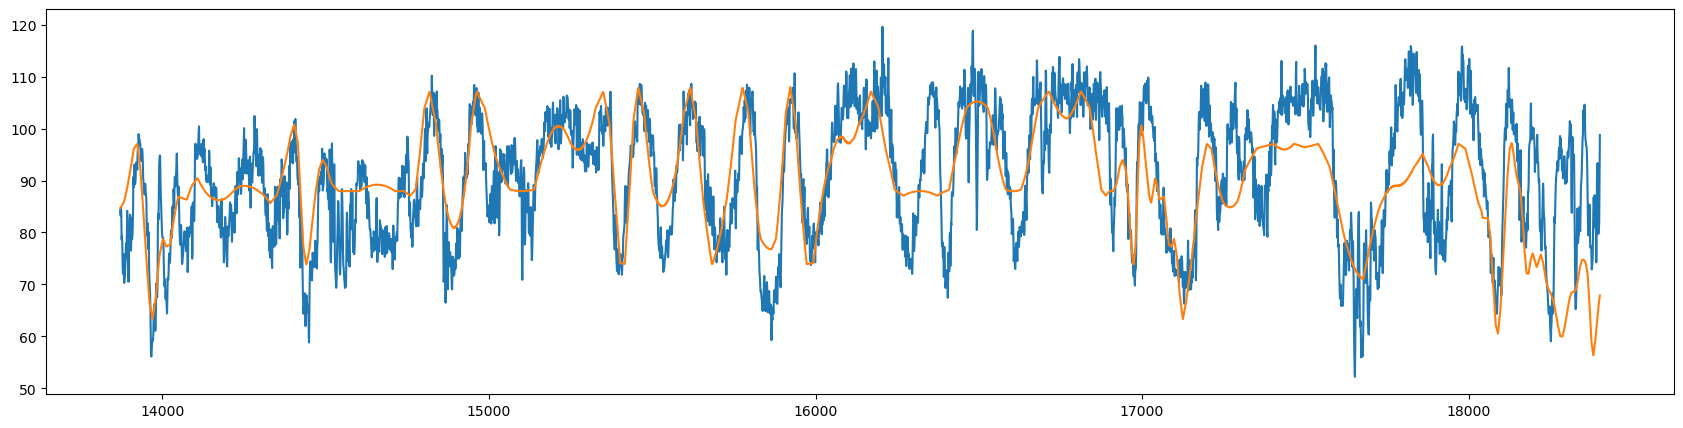

In [20]:
plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], gr)
plt.plot(evalz['MD'], all_pred_grs[2] + gr)

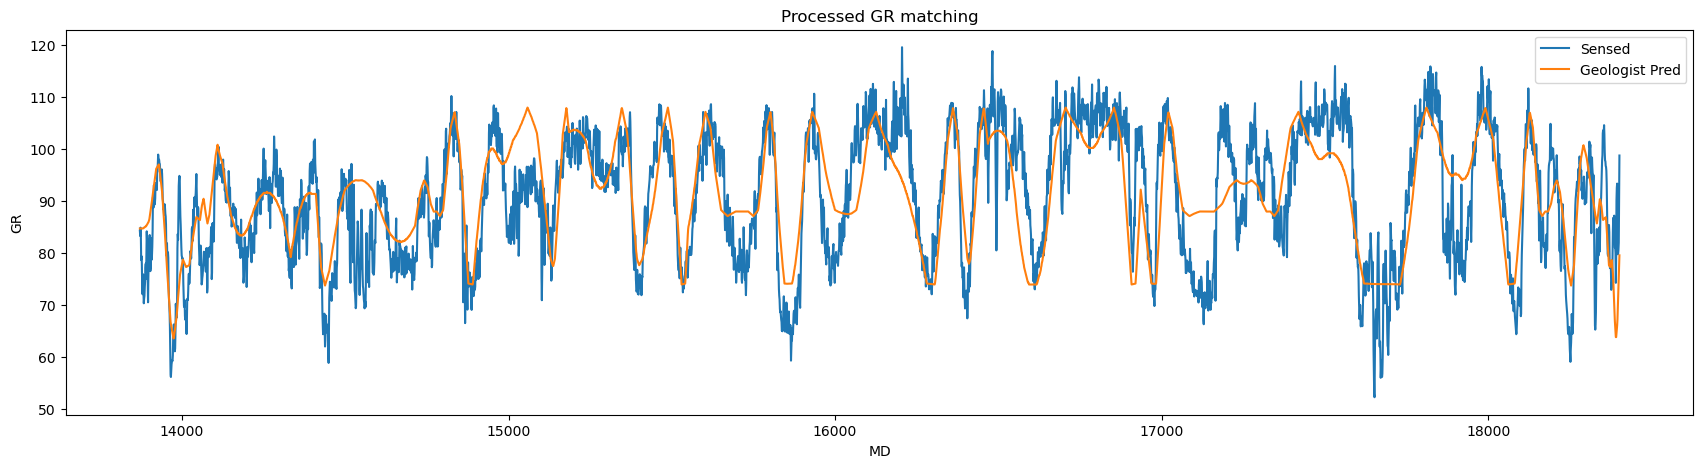

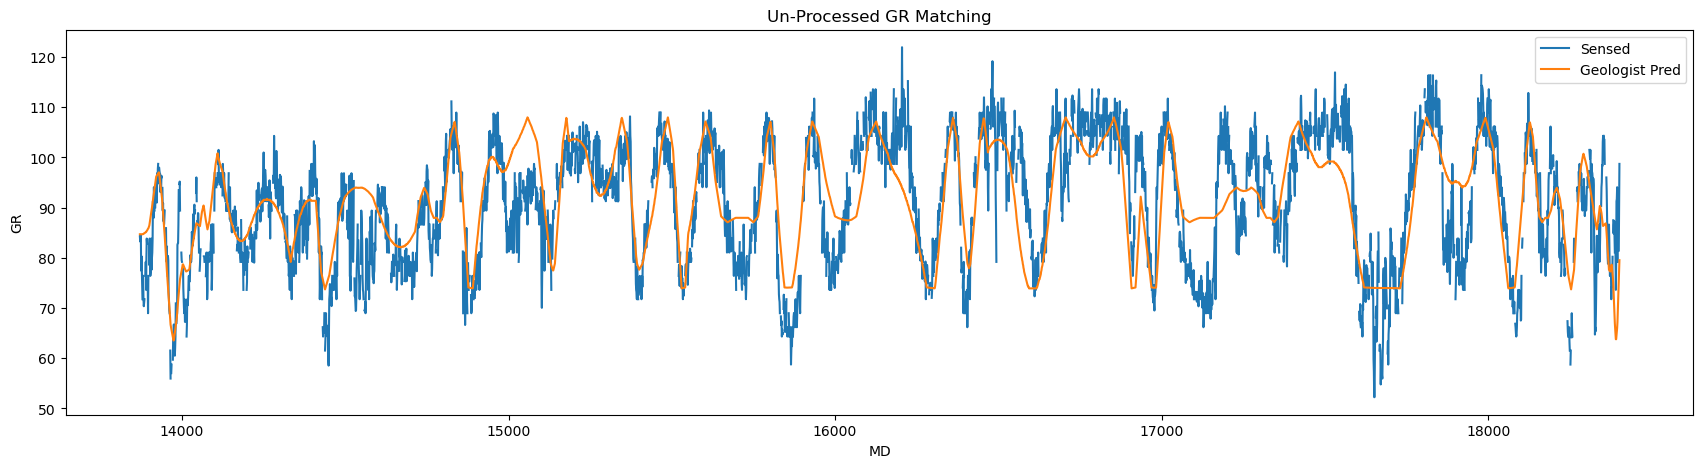

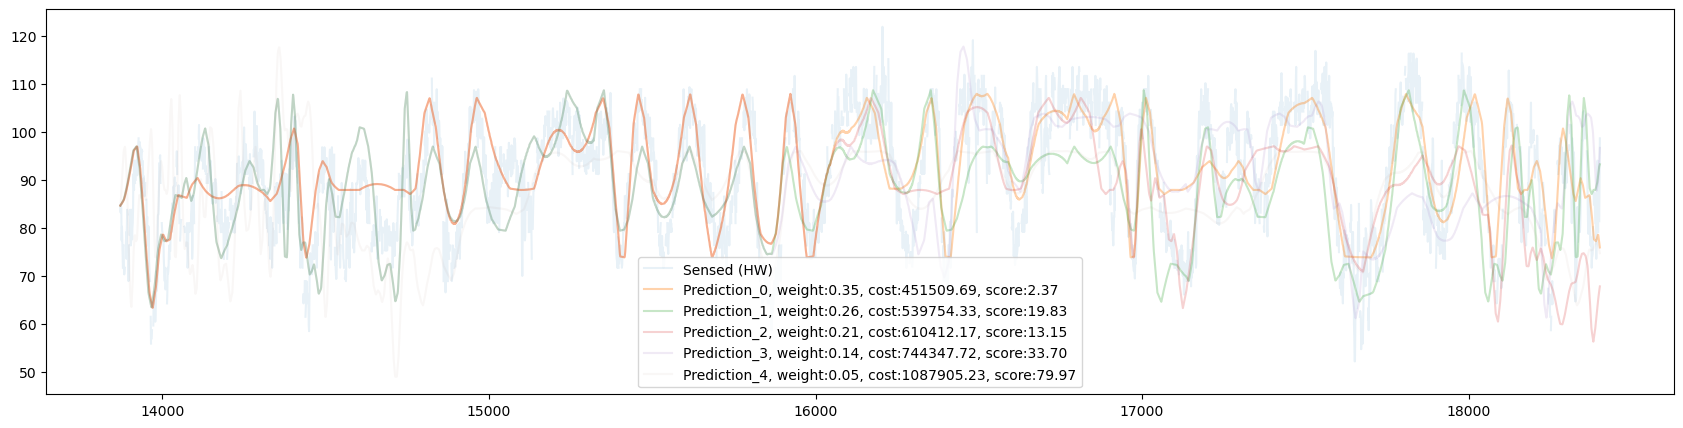

In [21]:
tvt = evalz['TVT']
md = evalz['MD']

plt.figure(figsize=(21, 5))
plt.title('Processed GR matching')
plt.plot(md, gr, label='Sensed')
plt.plot(md, np.interp(tvt, tw_tvt, tw_gr), label='Geologist Pred')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()

plt.figure(figsize=(21, 5))
plt.title('Un-Processed GR Matching')
plt.plot(md, evalz['GR'], label='Sensed')
plt.plot(md, np.interp(tvt, tw['TVT'], tw['GR']), label='Geologist Pred')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Sensed (HW)', alpha=0.1)
for i, (tvt_pred, gr_pred, w) in enumerate(zip(all_pred_tvts, all_pred_grs, weights)):
    plt.plot(evalz['MD'], gr_pred + gr, alpha=w, label=f'Prediction_{i}, weight:{w:.2f}, cost:{cost[i]:.2f}, score:{rmse(tvt_pred, tvt):.2f}')
plt.legend()

Text(0, 0.5, 'TVT')

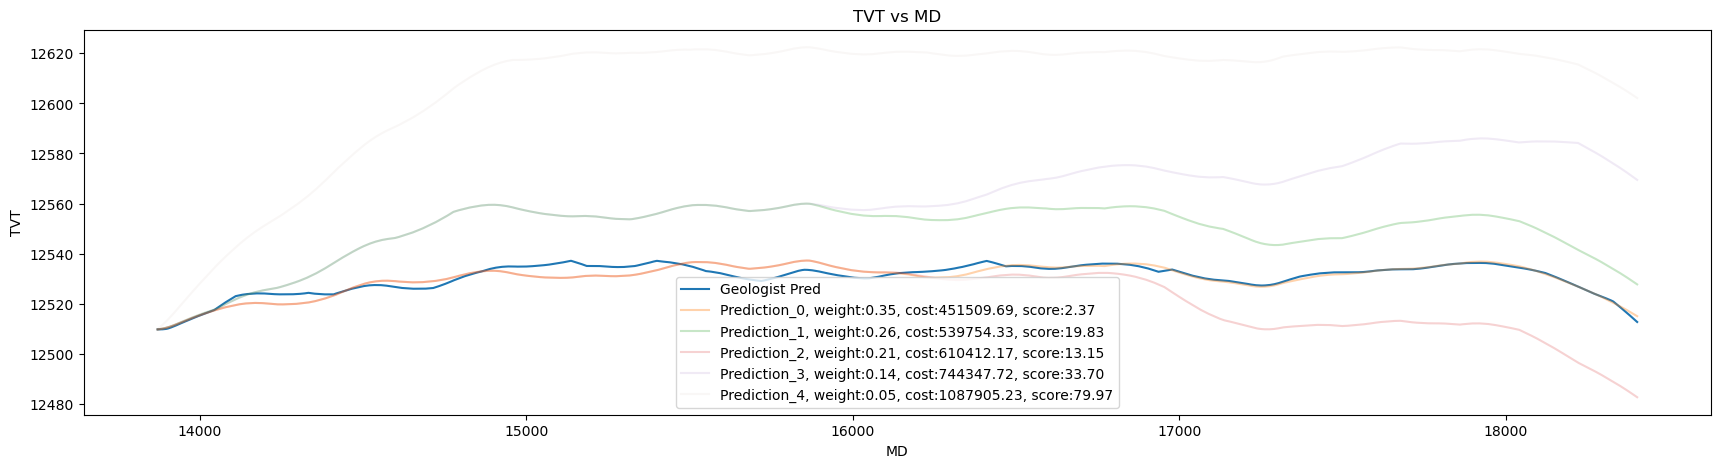

In [22]:
plt.figure(figsize=(21, 5))
plt.title('TVT vs MD')
plt.plot(evalz['MD'], tvt, label='Geologist Pred')
for i, (tvt_pred, w) in enumerate(zip(all_pred_tvts, weights)):
    plt.plot(evalz['MD'], tvt_pred, alpha=w, label=f'Prediction_{i}, weight:{w:.2f}, cost:{cost[i]:.2f}, score:{rmse(tvt_pred, tvt):.2f}')
plt.legend()
plt.xlabel('MD')
plt.ylabel('TVT')

In [23]:
m_z, c_z = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
evalz['pred_Z'] = m_z * evalz['MD'] + c_z - evalz['Z']
evalz['Z+TVT'] = evalz['TVT'] - evalz['pred_Z'] - tvt0
m_z

np.float64(-0.018850801286913802)

303002.9717419676
41407.87065691047
147344.03785094427
265984.80401040835
277434.9107530216


Text(0, 0.5, 'Z+TVT')

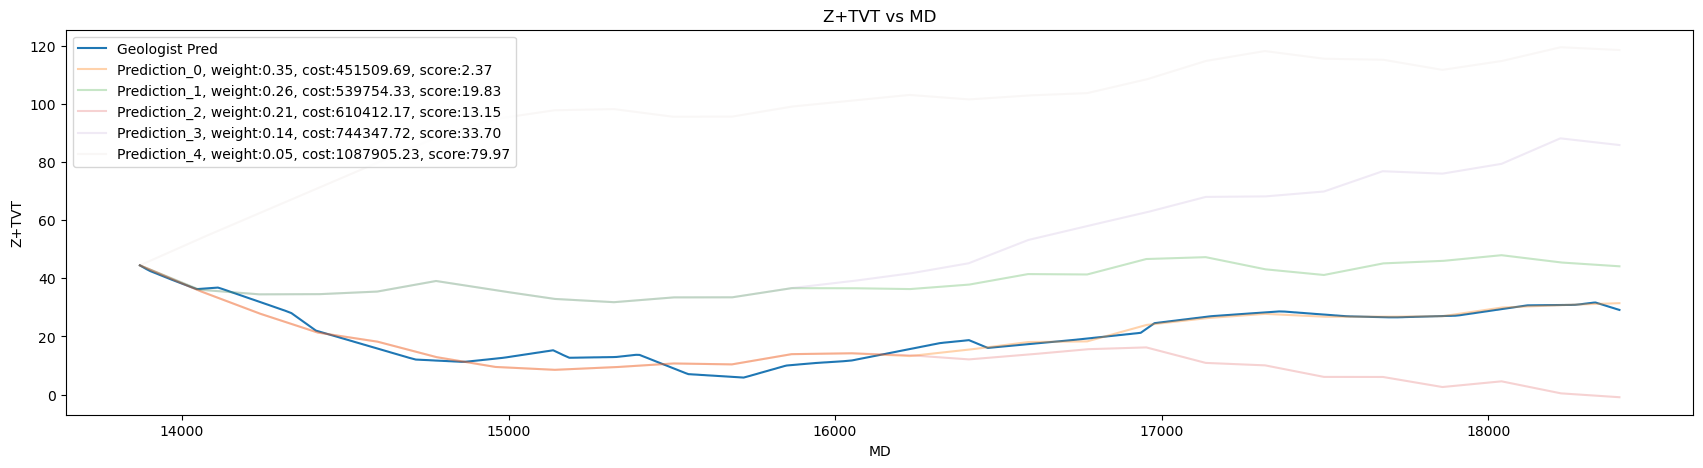

In [24]:
plt.figure(figsize=(21, 5))
plt.title('Z+TVT vs MD')
plt.plot(evalz['MD'], evalz['Z+TVT'], label='Geologist Pred')
for i, (ztvt_pred, tvt_pred, w) in enumerate(zip(all_pred_ztvts, all_pred_tvts, weights)):
    m_ztvt, c_ztvt = np.polyfit(evalz['MD'], ztvt_pred, deg=1)
    loss_reg = np.sum(np.square(ztvt_pred - evalz['MD'] * m_ztvt - c_ztvt))
    print(loss_reg)
    plt.plot(evalz['MD'], ztvt_pred, alpha=w, label=f'Prediction_{i}, weight:{w:.2f}, cost:{cost[i]:.2f}, score:{rmse(tvt_pred, tvt):.2f}')
plt.legend()
plt.xlabel('MD')
plt.ylabel('Z+TVT')

Text(0, 0.5, 'd(Z+TVT)')

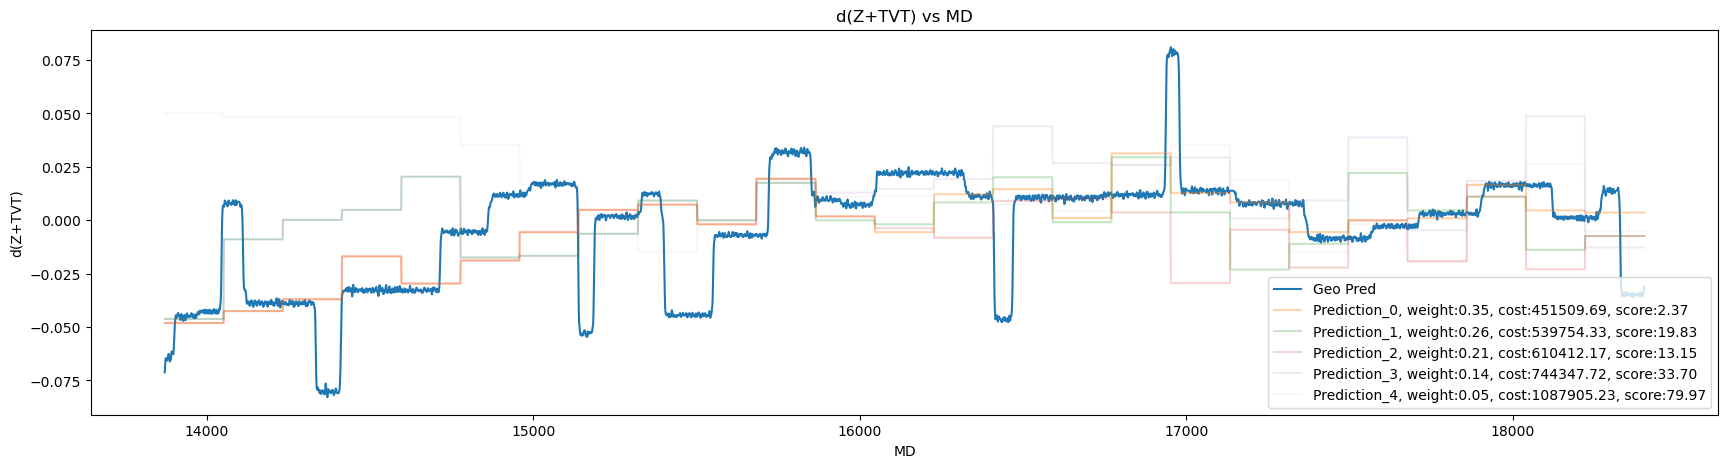

In [25]:
plt.figure(figsize=(21, 5))
plt.title('d(Z+TVT) vs MD')
plt.plot(evalz['MD'], remove_rotation_noise(evalz['Z+TVT'].diff().clip(upper=0.1, lower=-0.1), cutoff=0.1), label='Geo Pred')
for i, (m_pred, tvt_pred, w) in enumerate(zip(all_pred_ms, all_pred_tvts, weights)):
    plt.plot(evalz['MD'], m_pred, alpha=w, label=f'Prediction_{i}, weight:{w:.2f}, cost:{cost[i]:.2f}, score:{rmse(tvt_pred, tvt):.2f}')
plt.legend()
plt.xlabel('MD')
plt.ylabel('d(Z+TVT)')


## Saving Data
Features:
* For all the 5 predictions:
    * Z + TVT
    * Slopes
    * Costs
    * Boundaries

In [26]:
from tqdm import tqdm
df = []
wells = sorted(well_names[:])
# wells = ['fba7683c'] # Only well that didnt give 5 paths on some settings
groups = list()

print(f"Deploying Trained Physics-Informed Model on {len(wells)} wells...")
for well in tqdm((wells[:])):
    z, gr, tvt0, tw_gr, tw_tvt = pre_process(well)

    hw = pd.read_csv(f'../data/train/{well}__horizontal_well.csv')
    evalz = hw[hw['TVT_input'].isna()]
    boundaries = find_midpoints(evalz['MD'], (evalz['GR']), prominence=PEAK_PROMINENCE, distance=PEAK_DISTANCE)
    if len(z) < 1000:
        boundaries = np.linspace(0, len(z), len(z) // 70).astype(int)
    else:
        boundaries = np.linspace(0, len(z), len(z) // 170).astype(int)

    # Predicted 
    num_chunks = len(boundaries) - 1

    all_pred_ztvts, all_pred_tvts, weights, all_pred_ms, cost, all_pred_grs, all_pred_boundaries = find_ms(boundaries, z, gr, tvt0, tw_gr, tw_tvt) 
    
    # Features
    w = np.full(z.shape, well)

    # To predict
    tvt = evalz['TVT']
    m_z, c_z = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
    z_pred = m_z * evalz['MD'] + c_z - evalz['Z']
    y = evalz['TVT'] - z_pred - tvt0

    if len(all_pred_ms)==5:
        sub_df = np.vstack((m_z + all_pred_ms, all_pred_ms, all_pred_ztvts, all_pred_grs, all_pred_boundaries, y.values))
    else:
        delta = 5 - len(all_pred_ms)
        all_pred_ms = np.vstack([all_pred_ms, np.full((delta, len(all_pred_ms[0])), np.nan)])
        all_pred_ztvts = np.vstack([all_pred_ztvts, np.full((delta, len(all_pred_ms[0])), np.nan)])
        all_pred_grs = np.vstack([all_pred_grs, np.full((delta, len(all_pred_ms[0])), np.nan)])
        all_pred_boundaries = np.vstack([all_pred_boundaries, np.full((delta, len(all_pred_ms[0])), np.nan)])
        sub_df = np.vstack((m_z + all_pred_ms, all_pred_ms, all_pred_ztvts, all_pred_grs, all_pred_boundaries, y.values))
    groups.extend(w.tolist())
    df.append(sub_df)

    

Deploying Trained Physics-Informed Model on 773 wells...


  0%|▏                                                                                                                   | 1/773 [00:03<44:04,  3.43s/it]


KeyboardInterrupt: 

In [28]:
ds = pd.DataFrame(np.concat(df, axis=1).T, columns=['M0', 'M1', 'M2', 'M3', 'M4',
                                                    'm0', 'm1', 'm2', 'm3', 'm4',
                                                    'pred0', 'pred1', 'pred2', 'pred3', 'pred4', 
                                                    'GR0', 'GR1', 'GR2', 'GR3', 'GR4',
                                                    'B0', 'B1', 'B2', 'B3', 'B4',
                                                    'gt'])

In [29]:
ds['w'] = groups

In [30]:
ds.to_csv('../data/ztvt4.csv')